# DCGAN on MNIST
### Machine Learning and Its Applications Final Project

This notebook implements a **Deep Convolutional GAN (DCGAN)** trained on the MNIST handwritten digits dataset.

A GAN consists of two networks trained adversarially:
- **Generator (G)**: Takes a random noise vector z and learns to produce realistic fake images
- **Discriminator (D)**: Takes an image and learns to classify it as real or fake

Over training, G gets better at fooling D, and D gets better at catching G until G produces convincing digits.

**Reference papers:**
- Goodfellow et al., *Generative Adversarial Nets* (NeurIPS 2014): https://arxiv.org/abs/1406.2661
- Radford et al., *DCGAN* (2015): https://arxiv.org/abs/1511.06434

## 1. Setup and Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

#  Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Make output directory for saved image grids
os.makedirs('output_images', exist_ok=True)

Using device: cuda
GPU: Tesla T4


## 2. Hyperparameters

All key settings are defined here in one place for easy tuning.

In [ ]:
#  Hyperparameters
LATENT_DIM   = 100      # Size of the noise vector z fed into the Generator
IMAGE_SIZE   = 64       # Images resized to 64x64 for DCGAN conv layers
CHANNELS     = 1        # Grayscale (MNIST)
BATCH_SIZE   = 128
NUM_EPOCHS   = 50
LR           = 2e-4     # Learning rate (Adam, as in original DCGAN paper)
BETA1        = 0.5      # Adam beta1 (0.5 recommended for GANs)
NGF          = 64       # Generator feature map size
NDF          = 64       # Discriminator feature map size
SAVE_EVERY   = 5        # Save image grid every N epochs
FIXED_SEED   = 42

torch.manual_seed(FIXED_SEED)
np.random.seed(FIXED_SEED)
print('Hyperparameters set.')

Hyperparameters set.


## 3. Dataset and DataLoader

We use MNIST loaded via `torchvision`. Images are:
- Resized from 28×28 → 64×64 (standard for DCGAN conv architecture)
- Normalized to the range **[-1, 1]**. This matches the `tanh` output of the Generator

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Dataset size: 60000 images
Number of batches: 469


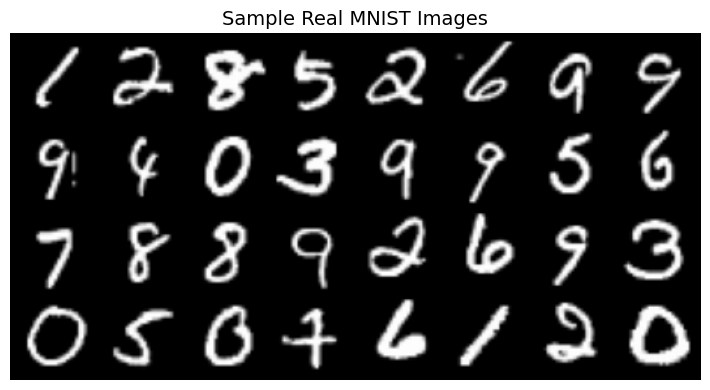

In [ ]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # Maps [0,1] -> [-1,1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print(f'Dataset size: {len(dataset)} images')
print(f'Number of batches: {len(dataloader)}')

#  Visualize a sample of real images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 4))
plt.axis('off')
plt.title('Sample Real MNIST Images', fontsize=14)
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0][:32], padding=2, normalize=True).cpu(),
        (1, 2, 0)
    ),
    cmap='gray'
)
plt.tight_layout()
plt.show()

## 4. Model Architecture

### Generator
The Generator takes a noise vector **z** of size `LATENT_DIM` and progressively upsamples it into an image using **transposed convolutional layers** (also called fractionally-strided convolutions):

```
z (100,) → reshape → 4×4 → 8×8 → 16×16 → 32×32 → 64×64 image
```

Each layer uses: `ConvTranspose2d → BatchNorm → ReLU`, with a final `Tanh` to output values in [-1, 1].

### Discriminator
The Discriminator mirrors the Generator. It takes a 64×64 image and progressively downsamples it using **standard convolutional layers**, ending with a single sigmoid output:

```
64×64 image → 32×32 → 16×16 → 8×8 → 4×4 → scalar probability
```

Each layer uses: `Conv2d → BatchNorm → LeakyReLU(0.2)`, which is standard for GAN discriminators.

In [ ]:
def weights_init(m):
    """
    Custom weight initialization as specified in the DCGAN paper.
    Conv and ConvTranspose weights: Normal(0, 0.02)
    BatchNorm weights: Normal(1.0, 0.02), bias: 0
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
class Generator(nn.Module):
    """
    DCGAN Generator.
    Input:  z vector of shape (batch_size, LATENT_DIM, 1, 1)
    Output: image of shape (batch_size, CHANNELS, 64, 64)

    Architecture (each block = ConvTranspose2d + BatchNorm + ReLU):
      z:        (N, 100, 1,  1)
      Block 1:  (N, NGF*8, 4,  4)   -- stride=1, no padding
      Block 2:  (N, NGF*4, 8,  8)   -- stride=2, padding=1
      Block 3:  (N, NGF*2, 16, 16)  -- stride=2, padding=1
      Block 4:  (N, NGF,   32, 32)  -- stride=2, padding=1
      Output:   (N, 1,     64, 64)  -- stride=2, padding=1, Tanh
    """
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Block 1: z → 4×4 feature maps
            nn.ConvTranspose2d(LATENT_DIM, NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8),
            nn.ReLU(True),

            # Block 2: 4×4 → 8×8
            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),

            # Block 3: 8×8 → 16×16
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),

            # Block 4: 16×16 → 32×32
            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),

            # Output: 32×32 → 64×64, Tanh squishes to [-1, 1]
            nn.ConvTranspose2d(NGF, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


# Instantiate and initialize
netG = Generator().to(device)
netG.apply(weights_init)
print('Generator Architecture:')
print(netG)
total_params = sum(p.numel() for p in netG.parameters())
print(f'\nTotal Generator parameters: {total_params:,}')

Generator Architecture:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)

In [ ]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator.
    Input:  image of shape (batch_size, CHANNELS, 64, 64)
    Output: scalar probability in [0, 1] (real=1, fake=0)

    Architecture (each block = Conv2d + BatchNorm + LeakyReLU(0.2)):
      Input:    (N, 1,     64, 64)
      Block 1:  (N, NDF,   32, 32)  -- no BatchNorm on first layer
      Block 2:  (N, NDF*2, 16, 16)
      Block 3:  (N, NDF*4, 8,  8)
      Block 4:  (N, NDF*8, 4,  4)
      Output:   (N, 1,     1,  1)  -- Conv2d + Sigmoid
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Block 1: 64×64 → 32×32 (no BatchNorm on input layer per DCGAN paper)
            nn.Conv2d(CHANNELS, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2: 32×32 → 16×16
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 3: 16×16 → 8×8
            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 4: 8×8 → 4×4
            nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: 4×4 → 1×1 scalar, Sigmoid for probability
            nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


# Instantiate and initialize
netD = Discriminator().to(device)
netD.apply(weights_init)
print('Discriminator Architecture:')
print(netD)
total_params = sum(p.numel() for p in netD.parameters())
print(f'\nTotal Discriminator parameters: {total_params:,}')

Discriminator Architecture:
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

T

## 5. Loss Function and Optimizers

Both networks use **Binary Cross Entropy (BCE)** loss:

$$\mathcal{L}_D = -\mathbb{E}[\log D(x)] - \mathbb{E}[\log(1 - D(G(z)))]$$

$$\mathcal{L}_G = -\mathbb{E}[\log D(G(z))]$$

We use **Adam** with `lr=2e-4` and `beta1=0.5`, as recommended in the DCGAN paper.

A **fixed noise vector** is also created, we generate images from it at each checkpoint so we can watch the same set of noise vectors evolve across training.

In [ ]:
#  Loss and Optimizers
criterion = nn.BCELoss()

# Convention: real label = 1, fake label = 0
real_label = 1.0
fake_label = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise to visualize progress across epochs using the same z vectors
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

print('Loss function: BCELoss')
print(f'Optimizer: Adam (lr={LR}, beta1={BETA1})')
print(f'Fixed noise shape: {fixed_noise.shape}')

Loss function: BCELoss
Optimizer: Adam (lr=0.0002, beta1=0.5)
Fixed noise shape: torch.Size([64, 100, 1, 1])


## 6. Training Loop

Each iteration alternates between two updates:

**Step 1 — Update Discriminator:**
1. Forward pass a batch of real images → compute loss with label=1
2. Generate fake images from noise → forward pass through D → compute loss with label=0
3. Total D loss = real loss + fake loss → backprop → update D weights

**Step 2 — Update Generator:**
1. Generate fake images from noise → forward pass through D
2. Compute G loss using label=1 (we *want* D to think these are real)
3. Backprop through D into G → update G weights only

We track `D(x)` (D's avg score on real images) and `D(G(z))` before and after G update to monitor the adversarial dynamic.

In [ ]:
#  Training
G_losses = []   # Generator loss per batch
D_losses = []   # Discriminator loss per batch
img_list = []   # Generated image grids at each checkpoint
checkpoint_epochs = []  # Which epochs were checkpointed

iters = 0
print('Starting training...')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    for i, (real_images, _) in enumerate(dataloader):

        #  Step 1: Update Discriminator
        netD.zero_grad()

        # (1a) Real images through D
        real_images = real_images.to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output_real = netD(real_images).view(-1)
        errD_real = criterion(output_real, label)
        errD_real.backward()
        D_x = output_real.mean().item()  # Avg D score on real images

        # (1b) Fake images through D
        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)

        output_fake = netD(fake_images.detach()).view(-1)  # .detach() stops grad flowing to G
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()
        D_G_z1 = output_fake.mean().item()  # Avg D score on fake images (before G update)

        errD = errD_real + errD_fake
        optimizerD.step()

        #  Step 2: Update Generator
        netG.zero_grad()

        # G wants D to output 1 (think fakes are real)
        label.fill_(real_label)
        output_after = netD(fake_images).view(-1)  # Re-evaluate with updated D
        errG = criterion(output_after, label)
        errG.backward()
        D_G_z2 = output_after.mean().item()  # Avg D score on fakes (after G update)
        optimizerG.step()

        #  Logging
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        iters += 1

    #  End of epoch: print summary
    avg_G = epoch_G_loss / len(dataloader)
    avg_D = epoch_D_loss / len(dataloader)
    print(f'[Epoch {epoch+1:>2}/{NUM_EPOCHS}]  '
          f'Loss_D: {avg_D:.4f}  Loss_G: {avg_G:.4f}  '
          f'D(x): {D_x:.4f}  D(G(z)): {D_G_z1:.4f} → {D_G_z2:.4f}')

    #  Save image grid checkpoint
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        with torch.no_grad():
            fake_grid = netG(fixed_noise).detach().cpu()
        grid = vutils.make_grid(fake_grid, padding=2, normalize=True)
        img_list.append(grid)
        checkpoint_epochs.append(epoch + 1)
        vutils.save_image(grid, f'output_images/epoch_{epoch+1:03d}.png')
        print(f'  → Saved image grid for epoch {epoch+1}')

print('=' * 60)
print('Training complete!')

Starting training...
[Epoch  1/50]  Loss_D: 0.5197  Loss_G: 5.7171  D(x): 0.9078  D(G(z)): 0.0669 → 0.0500
  → Saved image grid for epoch 1
[Epoch  2/50]  Loss_D: 0.6319  Loss_G: 2.4846  D(x): 0.8336  D(G(z)): 0.1114 → 0.0967
[Epoch  3/50]  Loss_D: 0.6297  Loss_G: 2.5631  D(x): 0.9928  D(G(z)): 0.6382 → 0.0004
[Epoch  4/50]  Loss_D: 0.6152  Loss_G: 2.9290  D(x): 0.9422  D(G(z)): 0.0545 → 0.0419
[Epoch  5/50]  Loss_D: 0.6029  Loss_G: 3.2885  D(x): 0.7179  D(G(z)): 0.3950 → 0.1491
  → Saved image grid for epoch 5
[Epoch  6/50]  Loss_D: 0.4948  Loss_G: 3.3374  D(x): 0.8990  D(G(z)): 0.0930 → 0.0452
[Epoch  7/50]  Loss_D: 0.5210  Loss_G: 3.2561  D(x): 0.6917  D(G(z)): 0.0250 → 0.0887
[Epoch  8/50]  Loss_D: 0.5335  Loss_G: 3.1754  D(x): 0.7792  D(G(z)): 0.3090 → 0.1731
[Epoch  9/50]  Loss_D: 0.5020  Loss_G: 3.2861  D(x): 0.9669  D(G(z)): 0.0825 → 0.0224
[Epoch 10/50]  Loss_D: 0.4410  Loss_G: 3.5109  D(x): 0.9330  D(G(z)): 0.0380 → 0.0585
  → Saved image grid for epoch 10
[Epoch 11/50]  Loss

## 7. Results

### 7.1 Generator and Discriminator Loss Curves

In a healthy GAN:
- Neither loss should collapse to 0
- Both losses should fluctuate but roughly stabilize over time
- `D(x)` should stay high (D correctly classifies real images)
- `D(G(z))` should rise from ~0 toward ~0.5 as G improves

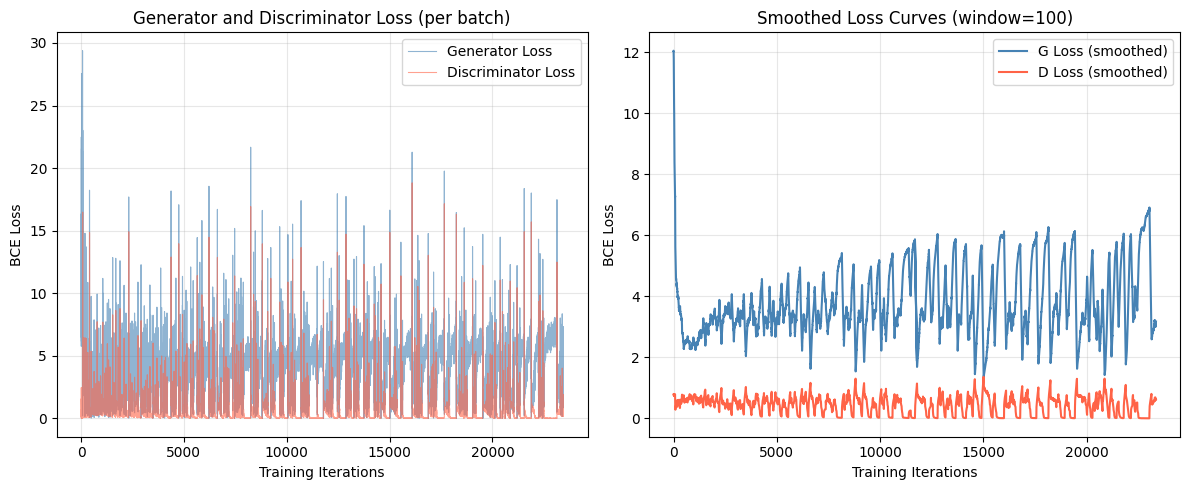

Loss curves saved to output_images/loss_curves.png


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(G_losses, label='Generator Loss', alpha=0.6, color='steelblue', linewidth=0.8)
plt.plot(D_losses, label='Discriminator Loss', alpha=0.6, color='tomato', linewidth=0.8)
plt.xlabel('Training Iterations')
plt.ylabel('BCE Loss')
plt.title('Generator and Discriminator Loss (per batch)')
plt.legend()
plt.grid(True, alpha=0.3)

# Smoothed version (moving average over 50 batches)
def moving_avg(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.subplot(1, 2, 2)
plt.plot(moving_avg(G_losses, 100), label='G Loss (smoothed)', color='steelblue', linewidth=1.5)
plt.plot(moving_avg(D_losses, 100), label='D Loss (smoothed)', color='tomato', linewidth=1.5)
plt.xlabel('Training Iterations')
plt.ylabel('BCE Loss')
plt.title('Smoothed Loss Curves (window=100)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_images/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved to output_images/loss_curves.png')

### 7.2 Generated Images Across Training Epochs

The same fixed noise vectors are passed through G at each checkpoint. This lets us directly compare the same "identities" across epochs and observe how the output quality evolves.

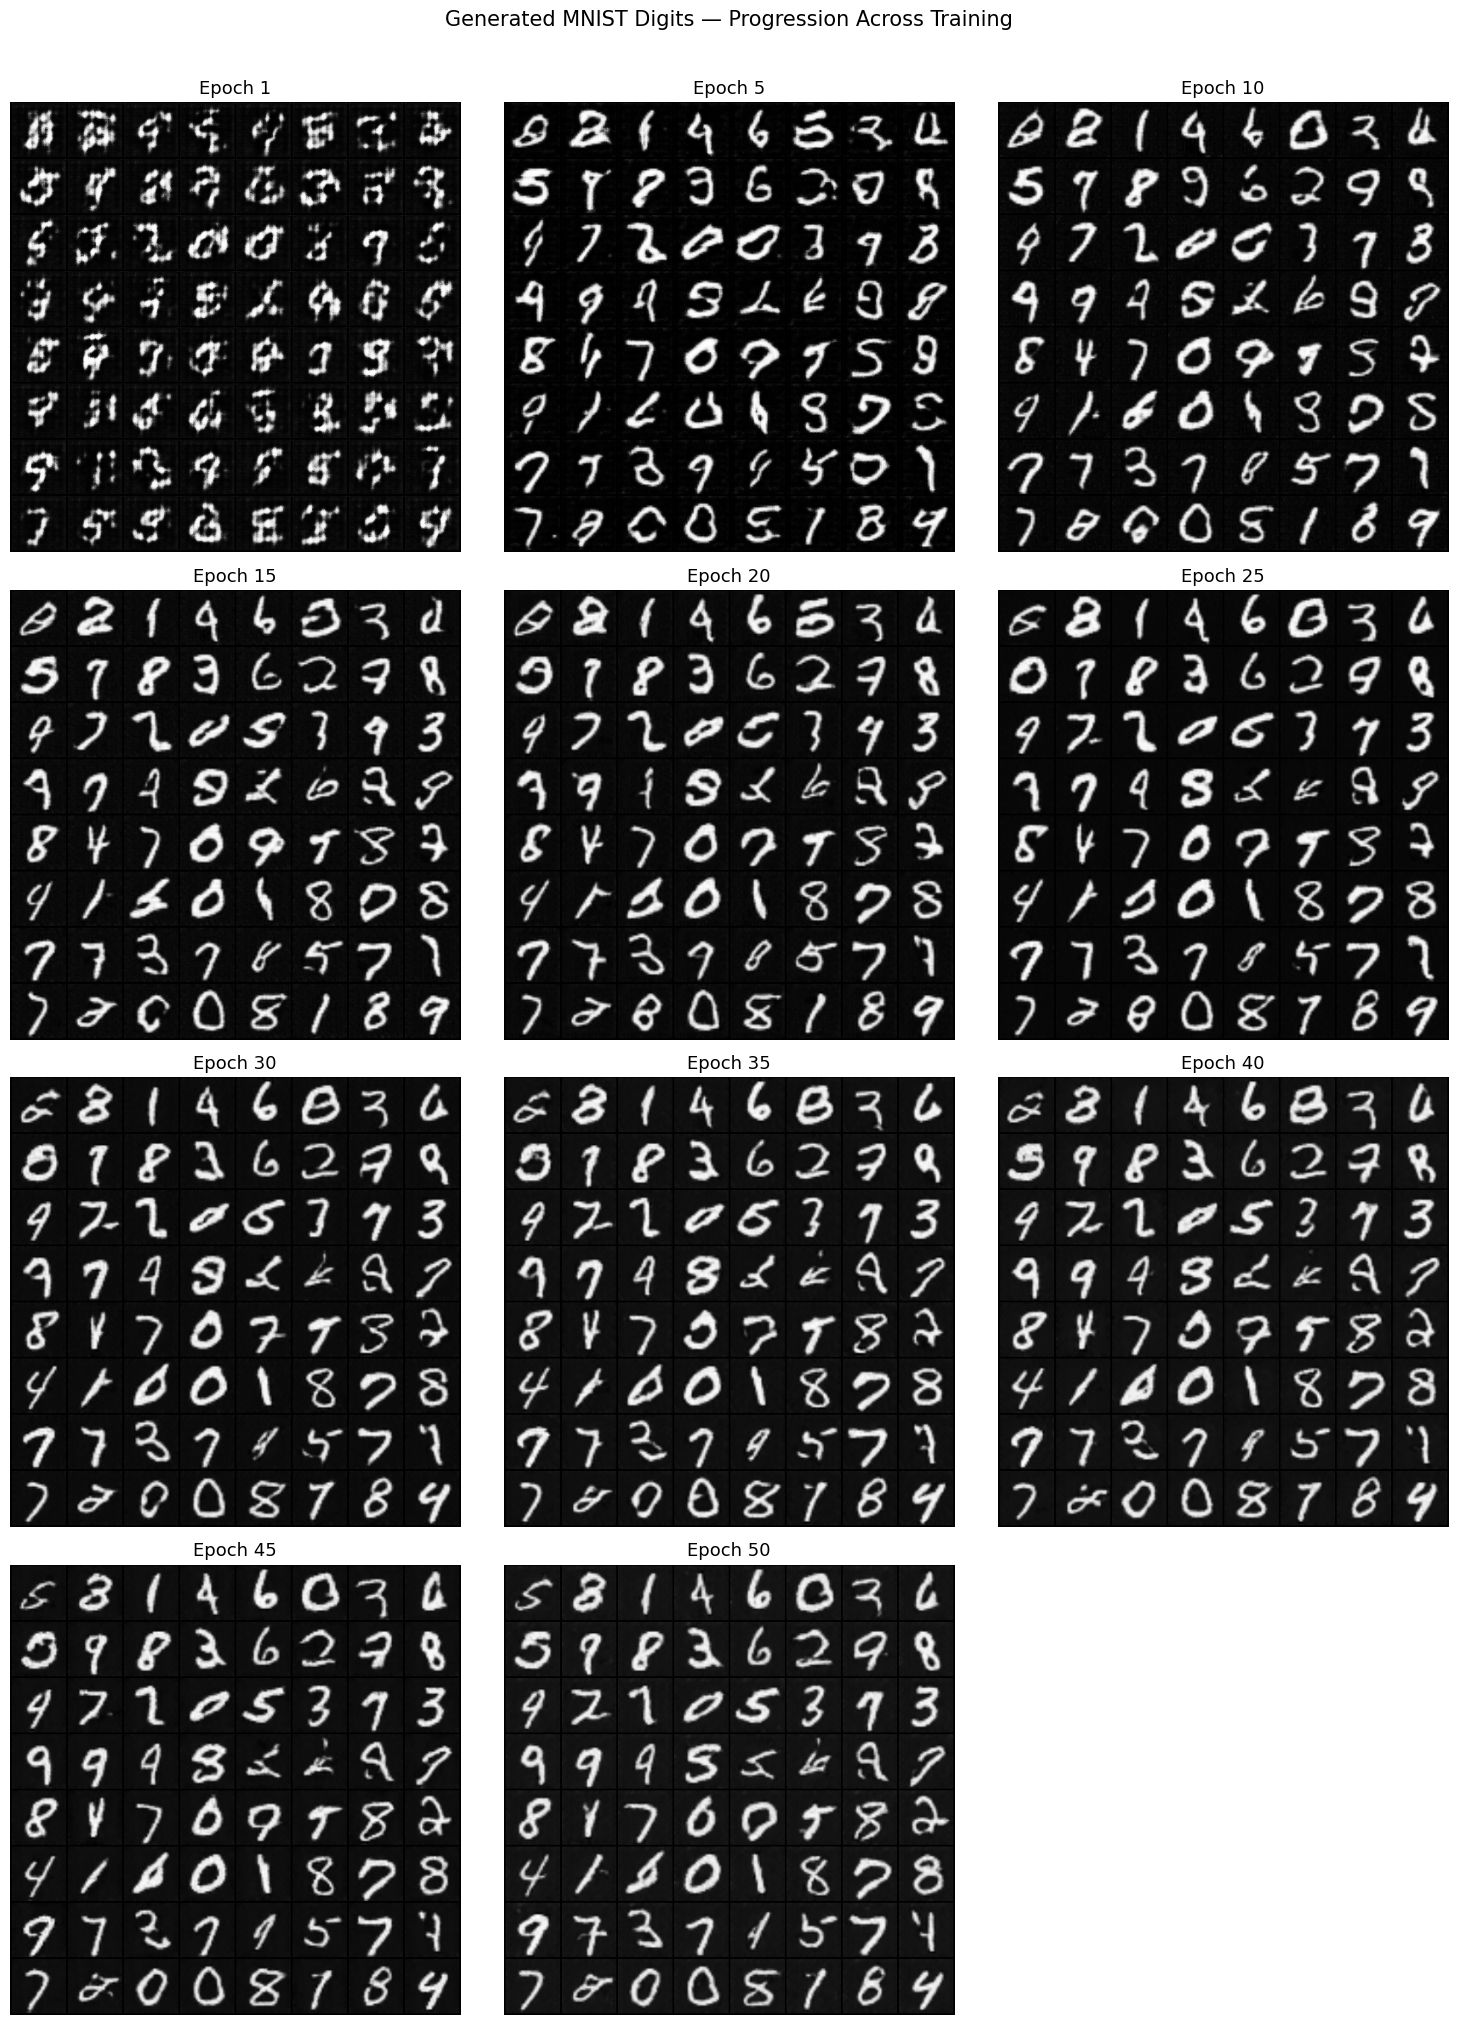

Progression grid saved to output_images/progression.png


In [ ]:
# Show all saved checkpoints in a grid layout
n_checkpoints = len(img_list)
cols = min(3, n_checkpoints)
rows = (n_checkpoints + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if n_checkpoints == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]

for idx, (grid, ep) in enumerate(zip(img_list, checkpoint_epochs)):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    ax.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    ax.set_title(f'Epoch {ep}', fontsize=13)
    ax.axis('off')

# Hide any unused subplot slots
for idx in range(n_checkpoints, rows * cols):
    r, c = divmod(idx, cols)
    axes[r][c].axis('off')

fig.suptitle('Generated MNIST Digits — Progression Across Training', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('output_images/progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Progression grid saved to output_images/progression.png')

### 7.3 Demo: Real vs. Generated Comparison

Side-by-side comparison of real MNIST digits (top) and digits generated by the fully-trained Generator (bottom).

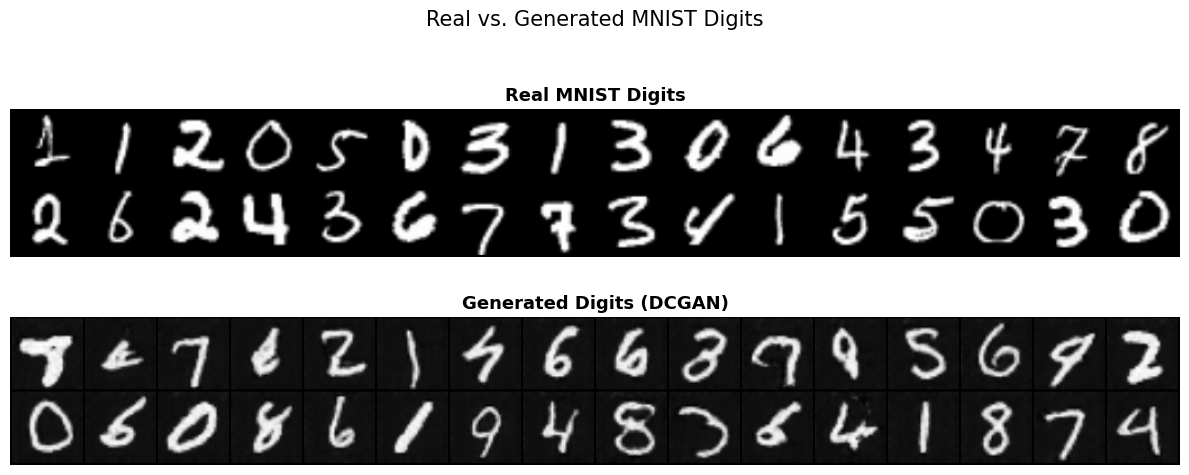

Real vs. fake comparison saved to output_images/real_vs_fake.png


In [ ]:
# Get a batch of real images
real_batch = next(iter(dataloader))
real_sample = real_batch[0][:32].cpu()

# Generate fake images using the trained Generator
with torch.no_grad():
    noise = torch.randn(32, LATENT_DIM, 1, 1, device=device)
    fake_sample = netG(noise).detach().cpu()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].imshow(
    np.transpose(vutils.make_grid(real_sample, nrow=16, padding=2, normalize=True).numpy(), (1, 2, 0)),
    cmap='gray'
)
axes[0].set_title('Real MNIST Digits', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(
    np.transpose(vutils.make_grid(fake_sample, nrow=16, padding=2, normalize=True).numpy(), (1, 2, 0)),
    cmap='gray'
)
axes[1].set_title('Generated Digits (DCGAN)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Real vs. Generated MNIST Digits', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('output_images/real_vs_fake.png', dpi=150, bbox_inches='tight')
plt.show()
print('Real vs. fake comparison saved to output_images/real_vs_fake.png')

## 8. Latent Space Interpolation (Bonus)

One interesting property of GANs is that the latent space is **smooth**, interpolating linearly between two noise vectors produces a smooth transition between two generated images. This shows the Generator has learned a meaningful internal representation.

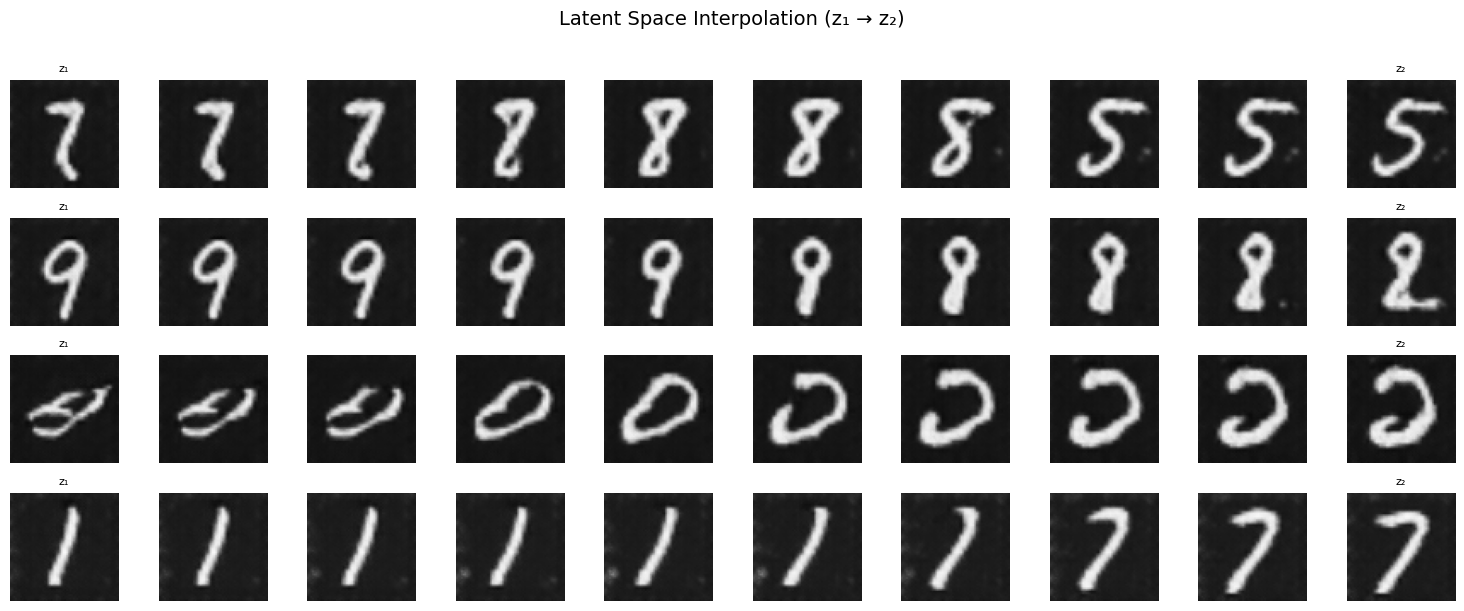

Interpolation plot saved to output_images/interpolation.png


In [ ]:
def interpolate_latent(z1, z2, steps=10):
    """Linearly interpolate between two latent vectors."""
    alphas = torch.linspace(0, 1, steps, device=device)
    return torch.stack([(1 - a) * z1 + a * z2 for a in alphas])

n_pairs = 4
steps = 10
fig, axes = plt.subplots(n_pairs, steps, figsize=(steps * 1.5, n_pairs * 1.5))

with torch.no_grad():
    for row in range(n_pairs):
        z1 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
        z2 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
        z_interp = interpolate_latent(z1.squeeze(), z2.squeeze(), steps=steps)
        z_interp = z_interp.unsqueeze(2).unsqueeze(3)  # reshape for G
        imgs = netG(z_interp).cpu()

        for col in range(steps):
            img = imgs[col].squeeze().numpy()
            img = (img + 1) / 2  # Denormalize [-1,1] → [0,1]
            axes[row][col].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_title('z₁', fontsize=8)
            elif col == steps - 1:
                axes[row][col].set_title('z₂', fontsize=8)

plt.suptitle('Latent Space Interpolation (z₁ → z₂)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output_images/interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpolation plot saved to output_images/interpolation.png')

## 9. Save the Trained Model

In [ ]:
torch.save(netG.state_dict(), 'generator_mnist.pth')
torch.save(netD.state_dict(), 'discriminator_mnist.pth')
print('Models saved: generator_mnist.pth, discriminator_mnist.pth')

Models saved: generator_mnist.pth, discriminator_mnist.pth


## 10. Summary and Discussion

### What was implemented
- A full **DCGAN** in PyTorch from scratch, following the architecture of Radford et al. (2015)
- Trained on **MNIST** for 50 epochs using **BCE loss** and **Adam** optimizer
- Generator: 5 transposed conv blocks, noise vector (100) → 64×64 image
- Discriminator: 5 conv blocks, 64×64 image → real/fake probability

### Adversarial Training Dynamic
- Early in training, the Discriminator easily distinguishes real from fake (D loss is low, G loss is high)
- As G improves, D must work harder — both losses converge toward an equilibrium
- Ideally, D(G(z)) → 0.5 at convergence (D can't tell real from fake)

### Key Design Decisions (from DCGAN paper)
| Choice | Reason |
|---|---|
| Strided conv instead of pooling | Learns its own downsampling |
| BatchNorm in G and D | Stabilizes training, helps gradient flow |
| ReLU in Generator | Covers full output range |
| LeakyReLU in Discriminator | Prevents dead neurons |
| Tanh output in G | Matches normalized [-1, 1] image range |
| Adam with β₁=0.5 | Recommended for GAN stability |

### Backup Direction
If needed, this project can pivot to **Variational Autoencoders (VAEs)**, which use a probabilistic latent space framework and an ELBO objective — distinct from both standard autoencoders and GANs.